# Optimization of strain-dependent terms in a free energy surface model of PTO

 
## Summary

Having derived the 3D free energy surface $\mathcal{G} (T, \boldsymbol{\mathcal{P}})$, we would like to further determine the 6D free energy surface $\mathcal{F}(T, \boldsymbol{\mathcal{P}}, \boldsymbol{\eta})$ for any given temperature $T$, polarization vector $\boldsymbol{\mathcal{P}}$, and orthogonal strain tensor $\boldsymbol{\eta}$. $\boldsymbol{\eta}$ is the first three components in the full strain tensor $\boldsymbol{\eta}_{all}=(\eta_{xx}, \eta_{yy}, \eta_{zz}, \eta_{xy}, \eta_{xz}, \eta_{yz})$. 

For a supercell with instantaneous cell parameters $\boldsymbol{l}=(l_x,l_y,l_z)$, we define the instantaneous strain components to be $\eta_i = \frac{l_i-l^{\text{ref}}_i(T)}{l^{\text{ref}}_i(T)}$ for $i=x,y,z$. The reference cell parameters $l^{\text{ref}}_i(T)$ are undetermined variables. 

The free energy surface $\mathcal{F}(T, \boldsymbol{\mathcal{P}}, \boldsymbol{\eta})$ is associated to $\mathcal{G} (T, \boldsymbol{\mathcal{P}})$ by the `thermodynamic consistency condition`:

$\exp(-\beta \mathcal{G} (T, \boldsymbol{\mathcal{P}})) = \int d\eta \exp(-\beta \mathcal{F}(T, \boldsymbol{\mathcal{P}}, \boldsymbol{\eta}))$


Within quadratic theory of elasticity and electrostriction, the `thermodynamic consistency condition` requires $\mathcal{F}  =\mathcal{G}  +  \frac{N}{2} (\boldsymbol{\eta}^T-\boldsymbol{Q}^T\hat{Z}^T) \hat{B} (\boldsymbol{\eta} - \hat{Z}\boldsymbol{Q})$ (see paper for explanation).

$\boldsymbol{Q}^T$ is the row vector $(\mathcal{P}_x^2, \mathcal{P}_y^2,\mathcal{P}_z^2)$.  The 3X3 matrix $\hat{Z}$ has equal diagonal elements ($Z_{11}(T)$) and equal off-diagonal elements ($Z_{12}(T)$). The 3X3 matrix  $\hat{B}$ has equal diagonal elements ($B_{11}(T)$) and equal off-diagonal elements ($B_{12}(T)$).

The goal of this Jupyter Notebook is to determine $l^{\text{ref}}_i(T), Z_{11}(T)$, $Z_{12}(T)$, $B_{11}(T)$, $B_{12}(T)$ from the trajectories of WT-MetaD simulation we obtained previously when we calculate $\mathcal{G} (T, \boldsymbol{\mathcal{P}})$. No new simulation is required. 


### Notes

X, Y, Z directions in this code is the Z, Y, X directions in the paper.


## Load packages and specify the size of the supercell and the list of temperature we want to work with.

In [7]:
import os
import numpy as np
from matplotlib import pyplot as plt
import matplotlib as mpl
## make ticks towards the inside
mpl.rcParams['xtick.direction'] = 'in'
mpl.rcParams['ytick.direction'] = 'in'
## set linewidth of the axes
mpl.rcParams['axes.linewidth'] = 1.5
plt.set_cmap('twilight')

k_B = 8.617333262e-5 #eV/K
e2C = 1.60217662e-19
e2uC = e2C * 1e6
Atcm=1e-8
temp_list= np.array([600, 700, 800, 820, 900, 1000])


<Figure size 640x480 with 0 Axes>

## Load WT-MetaD simulation trajectories, for each temperature separately.

The trajectories contain the following 1D array (length = number of samples):

`polar_x`: X-component of the instantaneous polarization ($\mathcal{P}_x$) of an atomic configuration.

`polar_y`: Y-component of the instantaneous polarization ($\mathcal{P}_x$) of an atomic configuration.

`polar_z`: Z-component of the instantaneous polarization ($\mathcal{P}_x$) of an atomic configuration.

`latt_x`: X-component of the instantaneous lattice constant ($l_x$), i.e. cell parameter, of the simulation box.

`latt_y`: Y-component of the instantaneous lattice constant ($l_y$), i.e. cell parameter, of the simulation box.

`latt_z`: Z-component of the instantaneous lattice constant ($l_z$), i.e. cell parameter, of the simulation box.


___Notes:___

X, Y, Z directions in this code is the Y, Z, X directions in the paper.
Z directions in this code is the dominant direction of spontaneous polarization. 

In [3]:
polar_x_all_temp = {}
polar_y_all_temp = {}
polar_z_all_temp = {}
latt_x_all_temp = {}
latt_y_all_temp = {}
latt_z_all_temp = {}

for temp in temp_list:
    ## load data from metadynamics simulation
    folder = r'../FES_3D/data/{}K9x9x9'.format(temp)
    plumed_stride = 10
    dt = 0.0005 * 1000
    throw = int(10/dt)
    plumed_out = np.loadtxt(os.path.join(folder, 'COLVAR'))[::plumed_stride]
    thermo_out = np.loadtxt(os.path.join(folder, 'pto.log'), skiprows=58, max_rows=plumed_out.shape[0])
    polar_x = plumed_out[throw:,  5 ]* e2uC / Atcm**2 ## P_x of sampled trajectory, shape (#frames)
    polar_y = plumed_out[throw:,  6 ]* e2uC / Atcm**2 ## P_y of sampled trajectory, shape (#frames)
    polar_z = plumed_out[throw:,  7 ]* e2uC / Atcm**2 ## P_z of sampled trajectory, shape (#frames)
    latt_x = thermo_out[throw:,  -3 ] / 9.0 ## average lattice constant along x-direction, from sampled trajectory, shape (#frames)
    latt_y = thermo_out[throw:,  -2 ] / 9.0 ## average lattice constant along y-direction, from sampled trajectory, shape (#frames)
    latt_z = thermo_out[throw:,  -1 ] / 9.0 ## average lattice constant along z-direction, from sampled trajectory, shape (#frames)
    polar_x_all_temp['{:d}K'.format(temp)] = polar_x
    polar_y_all_temp['{:d}K'.format(temp)] = polar_y
    polar_z_all_temp['{:d}K'.format(temp)] = polar_z
    latt_x_all_temp['{:d}K'.format(temp)] = latt_x
    latt_y_all_temp['{:d}K'.format(temp)] = latt_y
    latt_z_all_temp['{:d}K'.format(temp)] = latt_z



## Determine $l^{\text{ref}}_i(T), Z_{11}(T)$, $Z_{12}(T)$, $B_{11}(T)$, $B_{12}(T)$ from the data, for each temperature $T$ respectively

The determination of these parameters is divided into two steps 

__(1) Determine $l^{\text{ref}}_i(T), Z_{11}(T)$, $Z_{12}(T)$ by minimizing the L2-norm of the residual vector, given as  $L=\sum \|\boldsymbol{\eta}-\hat{Z}\boldsymbol{Q}\|^2$__

Although $\boldsymbol{Q}$ can be directly calculated from the data, $\boldsymbol{\eta}$ is unknown because $l^{\text{ref}}_i$ is undetermined. We need to tweak a bit the loss function, such that it can be converted to an optimization problem that can be directly solved by least squares. 

Notice $(\boldsymbol{\eta}-\hat{Z}\boldsymbol{Q})_i= \frac{l_i-l^{\text{ref}}_i}{l^{\text{ref}}_i} - \sum_j Z_{ij} \mathcal{P}_j^2=\frac{1}{l^{\text{ref}}_i} (l_i-l^{\text{ref}}_i - \sum_j l^{\text{ref}}_i Z_{ij} \mathcal{P}_j^2)$.

Based on that, we use an alternative loss function $L'=\sum_{i=x,y,z} L'_i =  \sum_{i=x,y,z}(l_i-l^{\text{ref}}_i - \sum_j l^{\text{ref}}_i Z_{ij} \mathcal{P}_j^2)^2$

Using the assumption that $l^{\text{ref}}=l^{\text{ref}}_x=l^{\text{ref}}_y=l^{\text{ref}}_z$ and $\hat{Z}$ has equal off-diagonal terms,  we have 

$L'_x = (l_x-l^{\text{ref}} -  l^{\text{ref}} Z_{11} \mathcal{P}_x^2 - l^{\text{ref}} Z_{12} (\mathcal{P}_y^2+\mathcal{P}_z^2))^2$

$L'_y = (l_y-l^{\text{ref}} -  l^{\text{ref}} Z_{11} \mathcal{P}_y^2 - l^{\text{ref}} Z_{12} (\mathcal{P}_x^2+\mathcal{P}_z^2))^2$

$L'_z = (l_z-l^{\text{ref}} -  l^{\text{ref}} Z_{11} \mathcal{P}_z^2 - l^{\text{ref}} Z_{12} (\mathcal{P}_x^2+\mathcal{P}_y^2))^2$

These are the setup of a least square problem treating $l^{\text{ref}}Z_{11}$, $l^{\text{ref}} Z_{12}$, and $l^{\text{ref}}$ as undetermined variables.  And the problem can be solved immediately with the standard implementation of least squares in numpy (`np.linalg.lstsq`). 



__(2) Determine $B_{11}(T)$, $B_{12}(T)$ using covariance matrix of the residue $\boldsymbol{\zeta}=\boldsymbol{\eta}-\hat{Z}\boldsymbol{Q}$__

We have obtained the optimal $l^{\text{ref}}$,  $Z_{11}$, and $Z_{12}$. With these optimal values, we are able to calculate the residue vector $\boldsymbol{\zeta}=\boldsymbol{\eta}-\hat{Z}\boldsymbol{Q}$ for the data. 

The obtained set of residue vectors obeys a three-dimensional normal distribution. And we can directly calculate the covariance matrix $\hat{\mathcal{C}}$ (`cov` in the code below) associated with the 3D normal distribution.  

$\hat{B}$ is associated with the covariance matrix by $\hat{\mathcal{C}}=(\beta N)^{-1}\hat{B}^{-1}$. $N$ is the total number of elementary cells. 

Therefore, we determine $\hat{B}$ as $\hat{B} = (\beta N) \hat{\mathcal{C}}^{-1}$. 

T=600, Z_11=7.682151232326723e-06, Z_12=-2.170044274678314e-06, l^ref=3.942A
T=700, Z_11=7.74020551393517e-06, Z_12=-2.290775029210326e-06, l^ref=3.947A
T=800, Z_11=7.814605598603974e-06, Z_12=-2.4149290442854766e-06, l^ref=3.952A
T=820, Z_11=7.83252812050116e-06, Z_12=-2.436209169527496e-06, l^ref=3.953A
T=900, Z_11=7.918593457843285e-06, Z_12=-2.5400718666992294e-06, l^ref=3.957A
T=1000, Z_11=8.052471117304897e-06, Z_12=-2.6666313743796746e-06, l^ref=3.962A


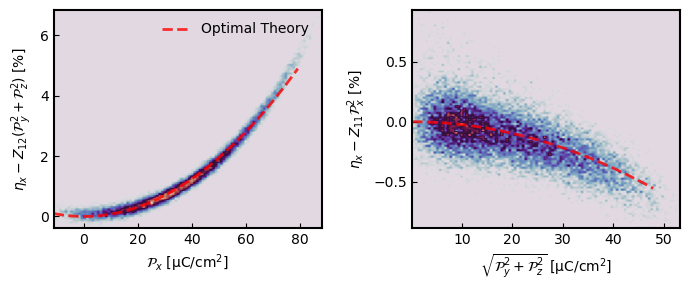

In [15]:
lref_list = []
B11_list = []
B12_list = []
Z1_list = []
Z2_list = []

for temp in  [600, 700, 800, 820, 900, 1000]:
    polar_x = polar_x_all_temp['{:d}K'.format(temp)]  
    polar_y = polar_y_all_temp['{:d}K'.format(temp)]  
    polar_z = polar_z_all_temp['{:d}K'.format(temp)]  
    latt_x = latt_x_all_temp['{:d}K'.format(temp)]  
    latt_y = latt_y_all_temp['{:d}K'.format(temp)]  
    latt_z = latt_z_all_temp['{:d}K'.format(temp)] 

    '''
    (1) We first solve l^ref, Z_11, and Z_12, with least-squares fitting
    '''
    ## preprocess
    variable_sector_1 = np.stack((polar_z**2, polar_x**2 + polar_y**2, np.ones_like(polar_z)), axis=1)  # (nframes, 3)
    variable_sector_2 = np.stack((polar_x**2, polar_z**2 + polar_y**2, np.ones_like(polar_x)), axis=1)  # (nframes, 3)
    variable_sector_3 = np.stack((polar_y**2, polar_x**2 + polar_z**2, np.ones_like(polar_y)), axis=1)  # (nframes, 3)
    variables = np.concatenate((variable_sector_1, variable_sector_2, variable_sector_3), axis=0)  # (3*nframes, 3)
    target = np.concatenate([latt_z, latt_x, latt_y], axis=0)  # (3*nframes)

    ## do least-squares fitting
    optimal_coef, _, rank, s = np.linalg.lstsq(variables, target, rcond=None)
    lref_z = optimal_coef[2]
    lref_x = lref_z
    lref_y = lref_z
    Z1 = optimal_coef[0] / optimal_coef[2]
    Z2 = optimal_coef[1] / optimal_coef[2]
    Z1_list.append(Z1)
    Z2_list.append(Z2)
    print('T={}, Z_11={}, Z_12={}, l^ref={:.3f}A'.format(temp, Z1, Z2, lref_z))
    lref_list.append(lref_z)

    '''
    (2) Then, we compute B_11 and B_12  
    '''
    # calculate strain_z
    strain_z = (latt_z - lref_z) / lref_z
    strain_x = (latt_x - lref_x) / lref_x
    strain_y = (latt_y - lref_y) / lref_y
    residuals_z = strain_z - Z1 * polar_z**2 - Z2 * (polar_x**2 + polar_y**2)
    residuals_x = strain_x - Z1 * polar_x**2 - Z2 * (polar_z**2 + polar_y**2)
    residuals_y = strain_y - Z1 * polar_y**2 - Z2 * (polar_z**2 + polar_x**2)

    # Z
    Z = np.array([ [Z1, Z2, Z2], [Z2, Z1, Z2], [Z2, Z2, Z1],])

    # calculate the residue vector
    residuals = np.stack([residuals_z, residuals_x, residuals_y], axis=1)
    
    # calculate the covariance matrix and regularize it into a matrix with the same diagonal terms and the same off-diagonal terms.
    cov = np.cov(residuals, rowvar=False)
    V1 = np.mean([cov[0,0], cov[1,1], cov[2,2]])
    V2 = np.mean([cov[0,1], cov[0,2], cov[1,2]])
    # print('cov', cov)
    V = np.array([[V1, V2, V2], [V2, V1, V2], [V2, V2, V1]])
    # Do matrix inversion and obtain B
    B = (k_B * temp) / 9**3 * np.linalg.inv(V)
    B11 = B[0,0]
    B12 = B[0,1]
    B11_list.append(B11)
    B12_list.append(B12)

    ## visualize the optimal fitting against distribution of data
    if temp==800:
        fig, ax = plt.subplots(1,2, figsize=(7,3))

        hist2d, xedges, yedges = np.histogram2d(polar_z, strain_z - Z2 * (polar_x**2 + polar_y**2), bins=(100,100), density=True)
        im = ax[0].imshow((hist2d).T, origin='lower', extent=[xedges[0], xedges[-1], yedges[0]*100, yedges[-1]*100], aspect='auto', label='Histogram')
        x_line = np.linspace(xedges[0], xedges[-1] * 0.9, 200)
        y_line = Z1 * x_line**2
        ax[0].plot(x_line, y_line * 100, color='red', linewidth=2,  linestyle='--', alpha=0.8, label='Optimal Theory')
        ax[0].set_xlabel(r'$\mathcal{P}_x$ $[\mathrm{\mu C/cm^2}]$')
        ax[0].set_ylabel(r'$\eta_x - Z_{12} (\mathcal{P}_y^2 + \mathcal{P}_z^2)$ [%]')
        ax[0].legend(frameon=False)
        
        # visualize 2D hist polar_x, strain_z and optimal fitting B
        hist2d, xedges, yedges = np.histogram2d( (polar_x**2 + polar_y**2)**0.5, strain_z - Z1 * polar_z**2, bins=(100,100), density=True)
        im = ax[1].imshow((hist2d).T, origin='lower', extent=[xedges[0], xedges[-1], yedges[0]*100, yedges[-1]*100], aspect='auto')
        x = np.linspace(xedges[0], xedges[-1] * 0.9, 200)
        # x = np.linspace(0,2500, 1000)
        y = Z2 * x**2
        ax[1].plot(x , y * 100, color='red', linewidth=2, linestyle='--', alpha=0.8)
        ax[1].set_xlabel(r'$\sqrt{\mathcal{P}_y^2 + \mathcal{P}_z^2}$ $[\mathrm{\mu C/cm^2}]$')
        ax[1].set_ylabel(r'$\eta_x - Z_{11} \mathcal{P}_x^2$ [%]')
        fig.tight_layout()

## Fit the temperature dependence of $l^{\text{ref}}_i(T), Z_{11}(T)$, $Z_{12}(T)$, $B_{11}(T)$, $B_{12}(T)$

__Summary__

Here we will do straightforward linear and quadratic fitting for the optimal $l^{\text{ref}}_i(T), Z_{11}(T)$, $Z_{12}(T)$, $B_{11}(T)$, $B_{12}(T)$ obtained in last step. 

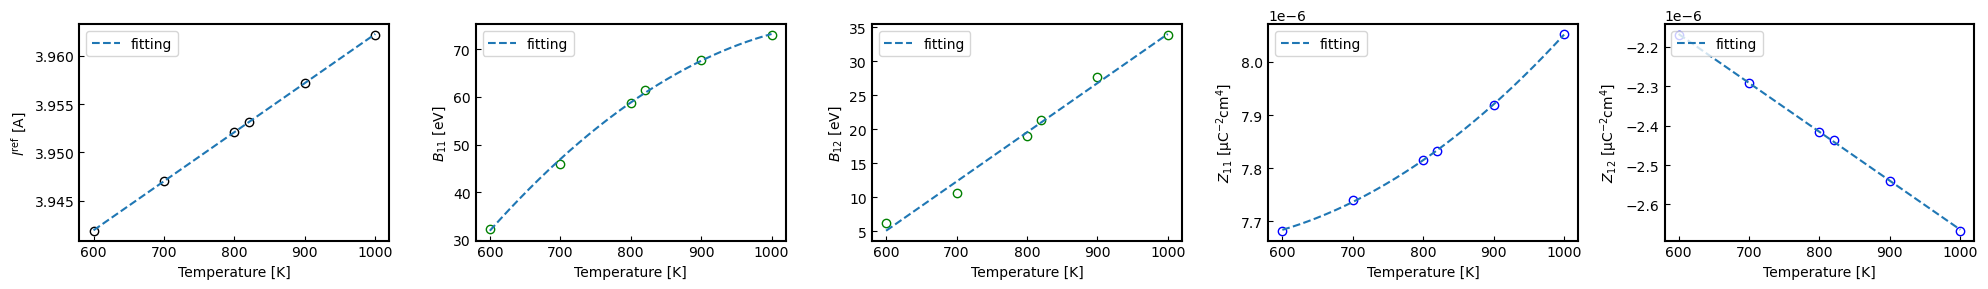

In [18]:
## Straightforward linear and quadratic fitting for all previously determined model parameters
temp_fit = np.linspace(min(temp_list), max(temp_list), 200)
m_l, b_l = np.polyfit(temp_list, lref_list, 1)
a_b11, m_b11,  b_b11  = np.polyfit(temp_list, B11_list,  2)
m_b12,  b_b12  = np.polyfit(temp_list, B12_list,  1)
a_z1,m_z1, b_z1 = np.polyfit(temp_list, Z1_list, 2)
m_z2, b_z2 = np.polyfit(temp_list, Z2_list, 1)

## plot the temperature dependence
fig, axes = plt.subplots(1, 5, figsize=(20, 3))

# 1) l_ref vs T
axes[0].plot(temp_list, lref_list, 'o-', markerfacecolor='white', color='black', linewidth=0)
y = m_l * temp_fit + b_l
axes[0].plot(temp_fit, y, '--', label='fitting')
axes[0].set_ylabel(r'$l^{\text{ref}}$ [A]')

# 2) B11 vs T
axes[1].plot(temp_list, B11_list, 'o-', markerfacecolor='white', color='g', linewidth=0)
y = a_b11 * temp_fit**2 + m_b11 * temp_fit + b_b11
axes[1].plot(temp_fit, y, '--', label='fitting')
axes[1].set_ylabel(r'$B_{11}$ [eV]')

# 3) B12 vs T
axes[2].plot(temp_list, B12_list, 'o-', markerfacecolor='white', color='g', linewidth=0)
y = m_b12 * temp_fit + b_b12
axes[2].plot(temp_fit, y, '--', label='fitting')
axes[2].set_ylabel(r'$B_{12}$ [eV]')

# 4) Z1 vs T
axes[3].plot(temp_list, Z1_list, 'o-', markerfacecolor='white', color='blue', linewidth=0)
y = a_z1 * temp_fit**2 + m_z1 * temp_fit + b_z1
axes[3].plot(temp_fit, y, '--', label='fitting')
axes[3].set_ylabel(r'$Z_{11}$ [$\mathrm{\mu C^{-2}cm^4}$]')

# 5) Z2 vs T
axes[4].plot(temp_list, Z2_list, 'o-', markerfacecolor='white', color='blue', linewidth=0)
y = m_z2 * temp_fit + b_z2
axes[4].plot(temp_fit, y, '--', label='fitting')
axes[4].set_ylabel(r'$Z_{12}$ [$\mathrm{\mu C^{-2}cm^4}$]')
for ax in axes:
    ax.set_xlabel('Temperature [K]')
    ax.legend(loc='upper left')
plt.tight_layout()
plt.show()


# Reproduce figures in the paper

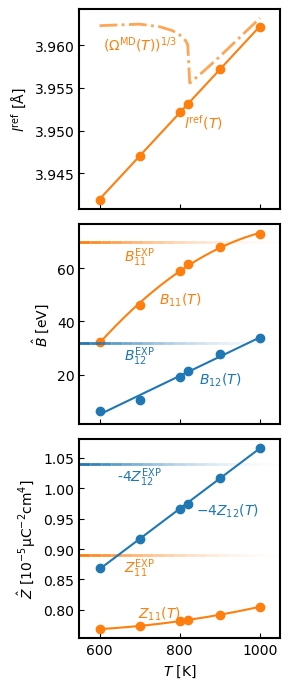

In [19]:
### experimental elastic modulus
elastic_scale_factor =  1.60218e-19 / 64.0e-30 / 1e9  # from eV to elastic module in unit of GPa
elastic_compliance = np.array([[8.0, -2.5, -2.5],[-2.5, 8.0, -2.5],[-2.5, -2.5, 8.0]])
elastic_module_exp = np.linalg.inv(elastic_compliance) * 1000   # GPa
elastic_module_exp = elastic_module_exp / elastic_scale_factor  # eV
exp_B11 = elastic_module_exp[0,0]
exp_B12 = elastic_module_exp[0,1]

### direct MD calculation of lattice constants,  Ref: PHYSICAL REVIEW B 111, 094113 (2025)
MD_temp = np.array([300, 400, 500, 600, 700, 750, 780, 790, 800, 810, 815, 820, 825, 830, 840, 850, 860, 870, 900, 1000])
MD_cubic_root_vol = np.array([3.9595046, 3.96067265, 3.96164924, 3.96232579, 3.96250239, 3.96219918, 
                     3.96177188, 3.9615371, 3.96123298, 3.96081748, 3.96052969, 3.96006569, 
                     3.95557812, 3.95576626, 3.95617662, 3.95657426, 3.95699458, 3.95740965, 
                     3.95870457, 3.96321657])



temp_fit = np.linspace(min(temp_list), max(temp_list), 200)
fig, axes = plt.subplots(3, 1, figsize=(3, 7), sharex=True)

# 1) l_ref vs T
ax = axes[0]
## plot experimental lattice constant
# ax.plot(exp_a_temp_dense_paraelectric, exp_a_const_dense_paraelectric, '--', markersize=0, color='blue', alpha = 0.3,linewidth=2)
# ax.plot(exp_root_vol_temp, exp_root_vol, '-.', markersize=0, color='tab:blue', alpha = 0.5,linewidth=2, label=r'$(\Omega^{\text{EXP}})^{1/3}$')
ax.plot(MD_temp[MD_temp>599], MD_cubic_root_vol[MD_temp>599], linestyle='-.', markersize=0, color='tab:orange', alpha = 0.7,linewidth=2, label=r'$(\Omega^{\text{MD}})^{1/3}$')
ax.annotate(r'$(\Omega^{\text{MD}}(T))^{1/3}$', xy=(600, 3.96), xytext=( 700, 3.959 ), color='tab:orange', alpha=1,fontsize=10, ha='center', va='bottom')
ax.plot(temp_list, lref_list, 'o-',  color='tab:orange', linewidth=0, label=r'$l^{\text{ref}}$')
# ax.legend(frameon=False)
## plot fitting result
y = m_l * temp_fit + b_l
ax.plot(temp_fit, y, '-', color='tab:orange')
ax.annotate(r'$l^{\text{ref}}(T)$', xy=(800, 3.95), xytext=( 860, 3.95 ), color='tab:orange', alpha=1,fontsize=10, ha='center', va='bottom')
ax.set_ylabel(r'$l^{\text{ref}}$ [$\mathrm{\AA}$]')
ax.set_xlim(550, 1050)
# ax.legend(  frameon=False) 

# 2) B11 vs T
ax = axes[1]
## plot B11
ax.plot(temp_list, B11_list, 'o-',   color='tab:orange', linewidth=0, label=r'$B_{11}(T)$')
y = a_b11 * temp_fit**2 + m_b11 * temp_fit + b_b11
ax.plot(temp_fit, y, '-', color='tab:orange')
ax.annotate(r'$B_{11}(T)$', xy=(600, 65), xytext=(800, 45 ), color='tab:orange', alpha=1,fontsize=10, ha='center', va='bottom')
## plot B11 experimental value
x_range = ax.get_xlim()
x_points = np.linspace(x_range[0], x_range[1], 20)
for i in range(len(x_points)-1):
    alpha = (1 - i/len(x_points))**2
    ax.plot([x_points[i], x_points[i+1]], [exp_B11, exp_B11], 
            linestyle='-.', color='tab:orange', alpha=alpha, linewidth=2)
ax.annotate(r'$B_{11}^{\text{EXP}}$', xy=(600, 65), xytext=(700, 60 ), color='tab:orange', alpha=1,fontsize=10, ha='center', va='bottom')
## plot B12
ax.plot(temp_list, B12_list, 'o-', color='tab:blue', linewidth=0, label=r'$B_{12}(T)$')
y = m_b12 * temp_fit + b_b12
ax.plot(temp_fit, y, '-', color='tab:blue')
ax.annotate(r'$B_{12}(T)$', xy=(600, 65), xytext=(900, 15 ), color='tab:blue', alpha=1,fontsize=10, ha='center', va='bottom')
## plot B12 experimental value: gradient line by plotting multiple segments with decreasing alpha
x_range = ax.get_xlim()
x_points = np.linspace(x_range[0], x_range[1], 20)
for i in range(len(x_points)-1):
    alpha = (1 - i/len(x_points))**2
    ax.plot([x_points[i], x_points[i+1]], [exp_B12, exp_B12], 
            linestyle='-.', color='tab:blue', alpha=alpha, linewidth=2)
ax.annotate(r'$B_{12}^{\text{EXP}}$', xy=(600, 30), xytext=(700, 23 ), color='tab:blue', alpha=1,fontsize=10, ha='center', va='bottom')
ax.set_ylabel(r'$\hat{B}$ [eV]')
# ax.legend( loc='upper left', frameon=False, fontsize=9, labelspacing=0.15) 
 
# 3) Z1 vs T
ax = axes[2]
Z1_exp = 0.089 * 1e-4 * 1e5   # Citation: J. Appl. Phys. 62, 3331 (1987); doi: 10.1063/1.339293
Z12_exp = -0.026 * 1e-4 * 1e5
## plot Z1 first
ax.plot(temp_list, np.array(Z1_list) * 1e5, 'o-', color='tab:orange', linewidth=0, label=r'$Z_{11}(T)$')
ax.annotate(r'$Z_{11}(T)$', xy=(600, 1.00), xytext=(750, 0.78 ), color='tab:orange', alpha=1,fontsize=10, ha='center', va='bottom')
y = a_z1 * temp_fit**2 + m_z1 * temp_fit + b_z1
ax.plot(temp_fit, y * 1e5, '-', color='tab:orange')
## plot Z1 experimental value
x_range = ax.get_xlim()
x_points = np.linspace(x_range[0], x_range[1], 20)
for i in range(len(x_points)-1):
    alpha = (1 - i/len(x_points))**2
    ax.plot([x_points[i], x_points[i+1]], [Z1_exp, Z1_exp], 
            linestyle='-.', color='tab:orange', alpha=alpha, linewidth=2)
ax.annotate(r'$Z_{11}^{\text{EXP}}$', xy=(900, 0.85), xytext=(700, 0.85 ), color='tab:orange', alpha=1,fontsize=10, ha='center', va='bottom')
## plot Z2
ax.plot(temp_list, -4 * np.array(Z2_list) * 1e5, 'o-',  color='tab:blue', linewidth=0, label=r'$-4Z_{12}(T)$')
ax.annotate(r'$-4Z_{12}(T)$', xy=(800, 0.95), xytext=(920, 0.95 ), color='tab:blue', alpha=1,fontsize=10, ha='center', va='bottom')
y = m_z2 * temp_fit + b_z2
ax.plot(temp_fit, -4 * y * 1e5, '-', color='tab:blue')
## plot Z2 experimental value
x_range = ax.get_xlim()
x_points = np.linspace(x_range[0], x_range[1], 20)
for i in range(len(x_points)-1):
    alpha = (1 - i/len(x_points))**2
    ax.plot([x_points[i], x_points[i+1]], [-4 * Z12_exp, -4 * Z12_exp], 
            linestyle='-.', color='tab:blue', alpha=alpha, linewidth=2)
ax.annotate(r'-4$Z_{12}^{\text{EXP}}$', xy=(600, 1.00), xytext=(700, 1.00 ), color='tab:blue', alpha=1,fontsize=10, ha='center', va='bottom')

ax.set_ylabel(r'$\hat{Z}$ $[\mathrm{10^{-5}\mu C^{-2} cm ^4}]$')
# ax.legend( loc='upper left', frameon=False, fontsize=9, labelspacing=0.15) 
ax.set_xlabel(r'$T$ [K]')
plt.tight_layout()
plt.savefig('fit_results.png', dpi=300)  


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


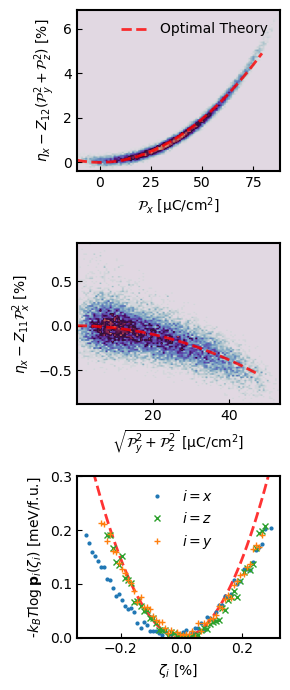

In [22]:
import matplotlib.colors as mcolors
temp = 800
idx = 2
nunits = 9 ** 3   ## total number of elementary cell
## the fitted value of relevant parameters
lref_fit = m_l * temp_list + b_l
B11_fit = a_b11 * temp_list**2 + m_b11 * temp_list + b_b11
B12_fit = m_b12 * temp_list + b_b12
Z1_fit = a_z1 * temp_list**2 + m_z1 * temp_list + b_z1
Z2_fit = m_z2 * temp_list + b_z2
lref = lref_fit[idx]
Z1, Z2 = Z1_fit[idx], Z2_fit[idx]

## plot
fig, ax = plt.subplots(3, 1, figsize=(3, 7))
polar_x, polar_y, polar_z = polar_x_all_temp['{:d}K'.format(temp)], polar_y_all_temp['{:d}K'.format(temp)], polar_z_all_temp['{:d}K'.format(temp)]
latt_x, latt_y, latt_z = latt_x_all_temp['{:d}K'.format(temp)], latt_y_all_temp['{:d}K'.format(temp)], latt_z_all_temp['{:d}K'.format(temp)]
strain_x = (latt_x - lref) / lref
strain_y = (latt_y - lref) / lref
strain_z = (latt_z - lref) / lref
residuals_z = strain_z - Z1 * polar_z**2 - Z2 * (polar_x**2 + polar_y**2)
residuals_x = strain_x - Z1 * polar_x**2 - Z2 * (polar_z**2 + polar_y**2)
residuals_y = strain_y - Z1 * polar_y**2 - Z2 * (polar_z**2 + polar_x**2)
## get the histogram and the corresponding logP
lb, ub = -0.005, 0.005
hist_z, bins_z = np.histogram(residuals_z, bins=100, range=(lb, ub), density=False)
hist_x, bins_x = np.histogram(residuals_x, bins=100, range=(lb, ub), density=False)
hist_y, bins_y = np.histogram(residuals_y, bins=100, range=(lb, ub), density=False)
## remove those too few data
filter_z = hist_z > 50
filter_x = hist_x > 50
filter_y = hist_y > 50
## compute logP
logP_z = np.log(hist_z[filter_z])  
logP_x = np.log(hist_x[filter_x])
logP_y = np.log(hist_y[filter_y])
bins_z = 0.5 * (bins_z[:-1] + bins_z[1:])[filter_z]
bins_x = 0.5 * (bins_x[:-1] + bins_x[1:])[filter_x]
bins_y = 0.5 * (bins_y[:-1] + bins_y[1:])[filter_y]
## compute corresponding free energy
numerical_energy_z = -k_B * temp * (logP_z - np.max(logP_z)) * 1000 / nunits  ## in meV/fu
numerical_energy_x = -k_B * temp * (logP_x - np.max(logP_x)) * 1000 / nunits
numerical_energy_y = -k_B * temp * (logP_y - np.max(logP_y)) * 1000 / nunits
predicted_energy_z = 0.5 * bins_z**2 * B[0,0] * 1000
predicted_energy_x = 0.5 * bins_x**2 * B[1,1] * 1000
predicted_energy_y = 0.5 * bins_y**2 * B[2,2] * 1000


hist2d, xedges, yedges = np.histogram2d(polar_z, strain_z - Z2 * (polar_x**2 + polar_y**2), bins=(100,100), density=True)
im = ax[0].imshow((hist2d).T, origin='lower', extent=[xedges[0], xedges[-1], yedges[0]*100, yedges[-1]*100], aspect='auto', label='Histogram')
x_line = np.linspace(xedges[0], xedges[-1] * 0.9, 200)
y_line = Z1 * x_line**2
ax[0].plot(x_line, y_line * 100, color='red', linewidth=2,  linestyle='--', alpha=0.8, label='Optimal Theory')
ax[0].set_xlabel(r'$\mathcal{P}_x$ $[\mathrm{\mu C/cm^2}]$')
ax[0].set_ylabel(r'$\eta_x - Z_{12} (\mathcal{P}_y^2 + \mathcal{P}_z^2)$ [%]')
ax[0].legend(frameon=False)

# visualize 2D hist polar_x, strain_z and optimal fitting B
hist2d, xedges, yedges = np.histogram2d( (polar_x**2 + polar_y**2)**0.5, strain_z - Z1 * polar_z**2, bins=(100,100), density=True)
im = ax[1].imshow((hist2d).T, origin='lower', extent=[xedges[0], xedges[-1], yedges[0]*100, yedges[-1]*100], aspect='auto')
x = np.linspace(xedges[0], xedges[-1] * 0.9, 200)
y = Z2 * x**2
ax[1].plot(x , y * 100, color='red', linewidth=2, linestyle='--', alpha=0.8)
ax[1].set_xlabel(r'$\sqrt{\mathcal{P}_y^2 + \mathcal{P}_z^2}$ $[\mathrm{\mu C/cm^2}]$')
ax[1].set_ylabel(r'$\eta_x - Z_{11} \mathcal{P}_x^2$ [%]')
ax[1].legend(frameon=False)

ax[2].plot(bins_z * 100, predicted_energy_z, '--',  color='red', linewidth=2, alpha=0.8,)
ax[2].plot(bins_z * 100, numerical_energy_z, 'o-', color='tab:blue', linewidth=0, label=r'$i=x$', markersize=2)
ax[2].plot(bins_x * 100, numerical_energy_x, 'x-', color='tab:green', linewidth=0, label=r'$i=z$', markersize=4)
ax[2].plot(bins_y * 100, numerical_energy_y, '+-', color='tab:orange', linewidth=0, label=r'$i=y$', markersize=4)
ax[2].set_xlabel(r'$\zeta_i$ [%]')
ax[2].set_ylabel(r'-$k_BT \log \mathbf{p}_i(\zeta_i)$ [meV/f.u.]')
ax[2].set_ylim(0,0.3)
ax[2].legend(loc='upper center', frameon=False, ncol=1)

plt.tight_layout()
plt.savefig('fit_validation.png', dpi=300)  